Import Data

In [1]:
import os

NOTEBOOK_FOLDER = os.path.basename(os.getcwd())
print(NOTEBOOK_FOLDER)

EDA


In [2]:
from dotenv import load_dotenv

# Walk up directories until we find .env
_dir = os.getcwd()
while _dir != os.path.dirname(_dir):
    if os.path.exists(os.path.join(_dir, ".env")):
        PROJECT_ROOT = _dir
        break
    _dir = os.path.dirname(_dir)

load_dotenv(os.path.join(PROJECT_ROOT, ".env"))

ORIGINAL_MATS_DIR = os.path.join(PROJECT_ROOT, str(os.getenv("ORIGINAL_MATS_DIR")))
WEIGHTS_DIR_LARRY = os.path.join(PROJECT_ROOT, str(os.getenv("WEIGHTS_DIR_LARRY")))
GRAPHS_DIR_LARRY = os.path.join(PROJECT_ROOT, str(os.getenv("VISUALS_DIR_LARRY")))
RESULTS_DIR_LARRY = os.path.join(PROJECT_ROOT, str(os.getenv("RESULTS_DIR_LARRY")))

NOTEBOOK_FOLDER = os.path.basename(os.getcwd())

WEIGHTS_DIR_LARRY = os.path.join(WEIGHTS_DIR_LARRY, NOTEBOOK_FOLDER)
GRAPHS_DIR_LARRY = os.path.join(GRAPHS_DIR_LARRY, NOTEBOOK_FOLDER)
RESULTS_DIR_LARRY = os.path.join(RESULTS_DIR_LARRY, NOTEBOOK_FOLDER)

os.makedirs(WEIGHTS_DIR_LARRY, exist_ok=True)
os.makedirs(GRAPHS_DIR_LARRY, exist_ok=True)
os.makedirs(RESULTS_DIR_LARRY, exist_ok=True)

train_data_path = os.path.join(ORIGINAL_MATS_DIR, "Labelled_0_1_2.npz")
infer_data_path = os.path.join(ORIGINAL_MATS_DIR, "third_batch.npz")

print("train_data_path:", train_data_path)
print("tests_data_path:", infer_data_path)

train_data_path: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\ORIGINAL MATS DONT MODIFY\Labelled_0_1_2.npz
tests_data_path: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\ORIGINAL MATS DONT MODIFY\third_batch.npz


In [3]:
import numpy as np
import pandas as pd

data = np.load(train_data_path)
infer_data__test = np.load(infer_data_path)

In [4]:

X = data["X"]
y = data["y"]

print("# of interactions:", X.shape[0])

print(
    "# of anomalous and normal users:",
    np.count_nonzero(y == 1),
    np.count_nonzero(y == 0),
)

XX = pd.DataFrame(X)
yy = pd.DataFrame(y)
XX.rename(columns={0: "user", 1: "item", 2: "rating"}, inplace=True)
print("# of items:", XX["item"].unique().shape[0])

# of interactions: 479433
# of anomalous and normal users: 260 2800
# of items: 998


In [5]:
# Filter anomalous (y=1) and normal (y=0) users
anomalous_users = yy[yy[1] == 1][0].values
normal_users = yy[yy[1] == 0][0].values

# Filter XX dataframe by user type
XX_anomalous = XX[XX['user'].isin(anomalous_users)]
XX_normal = XX[XX['user'].isin(normal_users)]

print(f"Anomalous users data: {XX_anomalous.shape[0]} interactions from {len(anomalous_users)} users")
print(f"Normal users data: {XX_normal.shape[0]} interactions from {len(normal_users)} users")

Anomalous users data: 35103 interactions from 260 users
Normal users data: 444330 interactions from 2800 users


In [6]:
XX_normal.head()

,user,item,rating
0,304,0,3
1,304,1,3
2,304,14,3
3,304,17,4
4,304,19,4


## FP-Growth Association Rule Mining

**Binarization:** Rating >= 4 → "Liked" (True), otherwise False.  
**Algorithm:** FP-Growth (no candidate generation, much faster than Apriori for dense data).

In [7]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Step 1: Binarize — True if user rated item >= 4
XX_normal["liked"] = XX_normal["rating"] >= 4

# Step 2: Pivot into user x item transaction matrix (one-hot)
basket = XX_normal[XX_normal["liked"]].pivot_table(
    index="user", columns="item", values="liked", aggfunc="max", fill_value=False
)

# Ensure all items are present as columns (even if no user liked them)
all_items = XX_normal["item"].unique()
missing = set(all_items) - set(basket.columns)
for col in missing:
    basket[col] = False

basket = basket.astype(bool)
print(f"Transaction matrix: {basket.shape[0]} users x {basket.shape[1]} items")
basket.head()

Transaction matrix: 2796 users x 998 items


item,0,1,2,3,4,5,6,7,8,9,...,848,951,976,980,949,887,984,732,573,958
user,,,,,,,,,,,,,,,,,,,,,
100,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
101,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
102,True,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
103,False,True,False,False,False,False,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False
104,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
# Step 3: Run FP-Growth to find frequent itemsets
frequent_itemsets = fpgrowth(basket, min_support=0.1, use_colnames=True)
print(f"Found {len(frequent_itemsets)} frequent itemsets")
frequent_itemsets.sort_values("support", ascending=False).head(20)

Found 92314 frequent itemsets


,support,itemsets
0,0.566166,frozenset({72})
32,0.555794,frozenset({67})
1,0.547210,frozenset({408})
33,0.526466,frozenset({127})
2,0.503577,frozenset({80})
3,0.493205,frozenset({61})
4,0.466023,frozenset({209})
34,0.461373,frozenset({454})
35,0.447067,frozenset({19})
36,0.438841,frozenset({112})


In [9]:
# Step 4: Generate association rules (lift >= 1.2)
rules = association_rules(
    frequent_itemsets, metric="lift", min_threshold=1.2,
    num_itemsets=len(frequent_itemsets)
)
rules = rules.sort_values("lift", ascending=False)
print(f"Found {len(rules)} association rules")
rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)

Found 1762406 association rules


,antecedents,consequents,support,confidence,lift
1762405,frozenset({142}),frozenset({202}),0.103362,0.865269,5.692455
1762404,frozenset({202}),frozenset({142}),0.103362,0.680000,5.692455
1438349,"frozenset({698, 594, 637})","frozenset({408, 690, 676})",0.109084,0.782051,5.372519
1438332,"frozenset({408, 690, 676})","frozenset({698, 594, 637})",0.109084,0.749386,5.372519
1440005,"frozenset({676, 61, 454})","frozenset({209, 698})",0.101931,0.760000,5.366061
1440020,"frozenset({209, 698})","frozenset({676, 61, 454})",0.101931,0.719697,5.366061
1437797,"frozenset({408, 690, 676})","frozenset({698, 67, 637})",0.100501,0.690418,5.362244
1437796,"frozenset({698, 67, 637})","frozenset({408, 690, 676})",0.100501,0.780556,5.362244
1437511,"frozenset({690, 67, 676})","frozenset({698, 594, 637})",0.106938,0.747500,5.359000
1437530,"frozenset({698, 594, 637})","frozenset({690, 67, 676})",0.106938,0.766667,5.359000


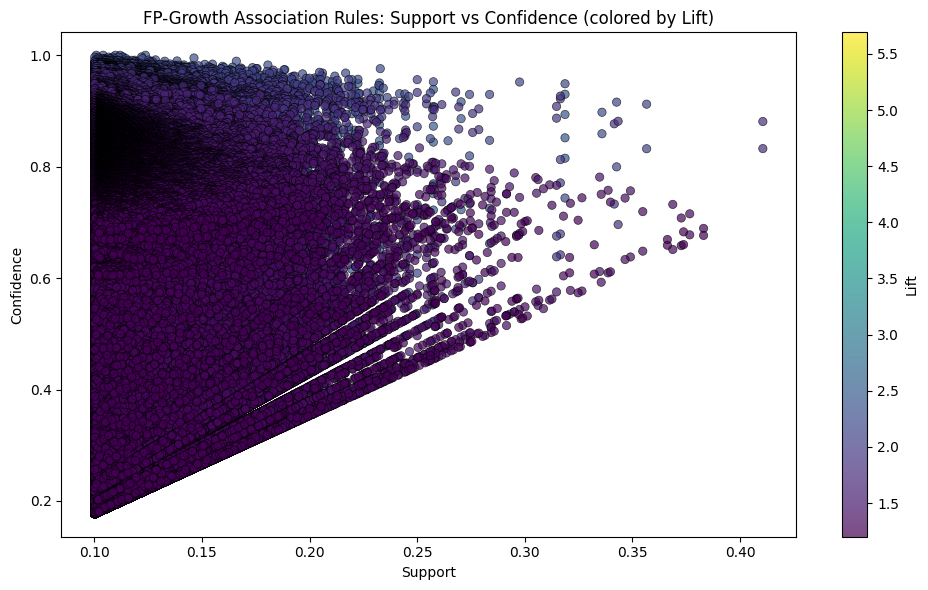

In [10]:
# Step 5: Visualize Support vs Confidence, colored by Lift
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    rules["support"], rules["confidence"],
    c=rules["lift"], cmap="viridis", alpha=0.7, edgecolors="k", linewidth=0.5
)
plt.colorbar(scatter, label="Lift")
ax.set_xlabel("Support")
ax.set_ylabel("Confidence")
ax.set_title("FP-Growth Association Rules: Support vs Confidence (colored by Lift)")
plt.tight_layout()
plt.show()

## Directed Network Graph

Nodes = items, edges = rules (antecedent → consequent).  
Edge thickness ∝ support, edge color ∝ lift.

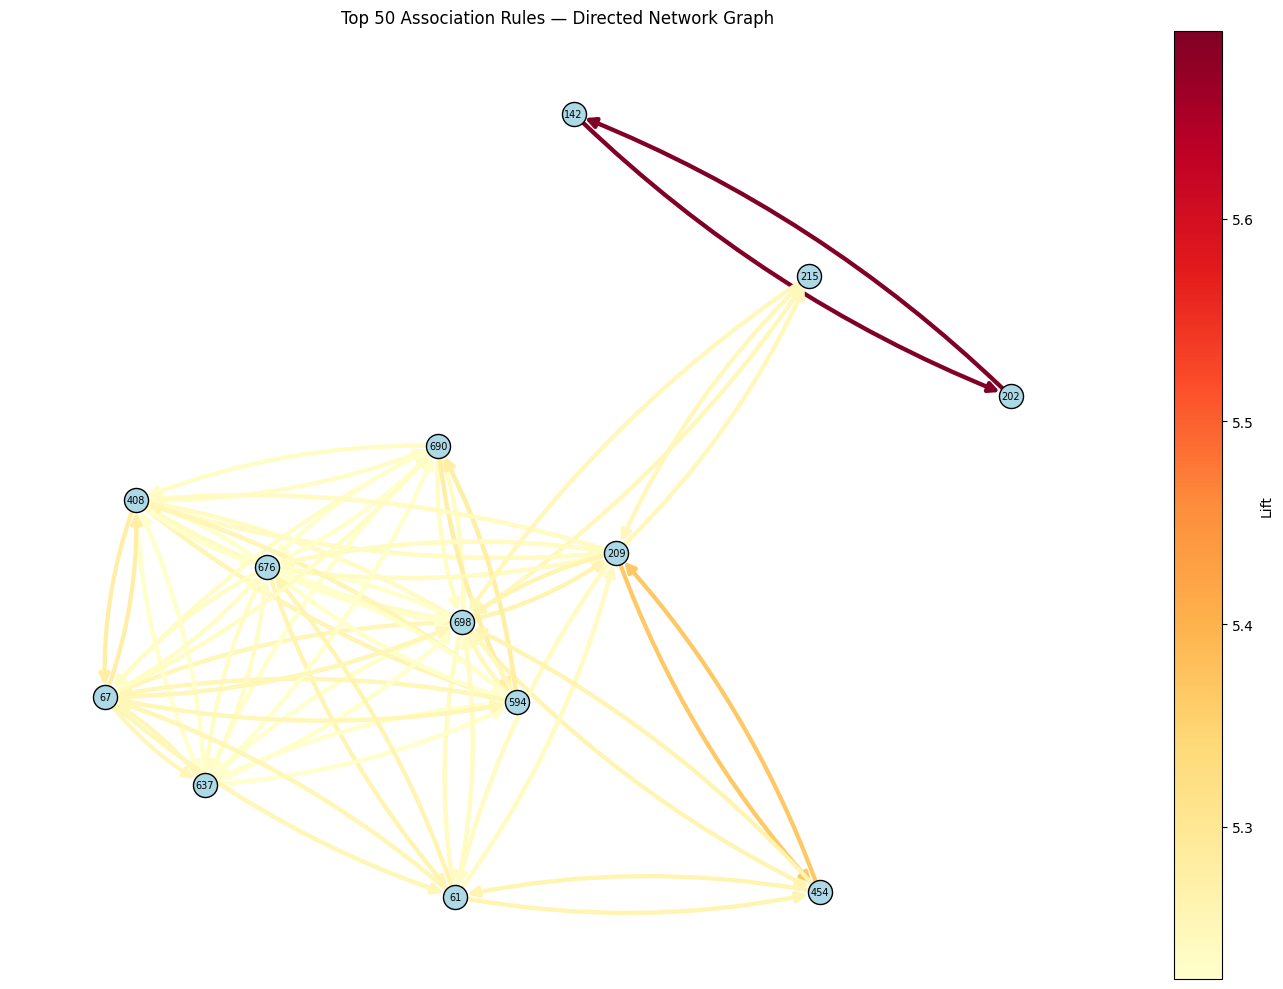

In [11]:
import networkx as nx
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Filter to top rules by lift for readability
top_rules = rules.nlargest(50, "lift")

G = nx.DiGraph()
for _, row in top_rules.iterrows():
    for ant in row["antecedents"]:
        for con in row["consequents"]:
            G.add_edge(ant, con, support=row["support"], lift=row["lift"])

# Edge attributes
edges = G.edges(data=True)
edge_lifts = [d["lift"] for _, _, d in edges]
edge_widths = [d["support"] * 30 for _, _, d in edges]  # scale for visibility

norm = Normalize(vmin=min(edge_lifts), vmax=max(edge_lifts))
cmap = plt.cm.YlOrRd
edge_colors = [cmap(norm(l)) for l in edge_lifts]

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=1.5, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=300, node_color="lightblue", edgecolors="black", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors,
                       arrows=True, arrowsize=15, connectionstyle="arc3,rad=0.1", ax=ax)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Lift")
ax.set_title("Top 50 Association Rules — Directed Network Graph")
ax.axis("off")
plt.tight_layout()
plt.show()

## Matrix Plot (Clustered Heatmap)

Antecedents on Y-axis, consequents on X-axis, cell color = Lift.  
Clustering reorders axes to reveal blocks of co-associated items.

c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


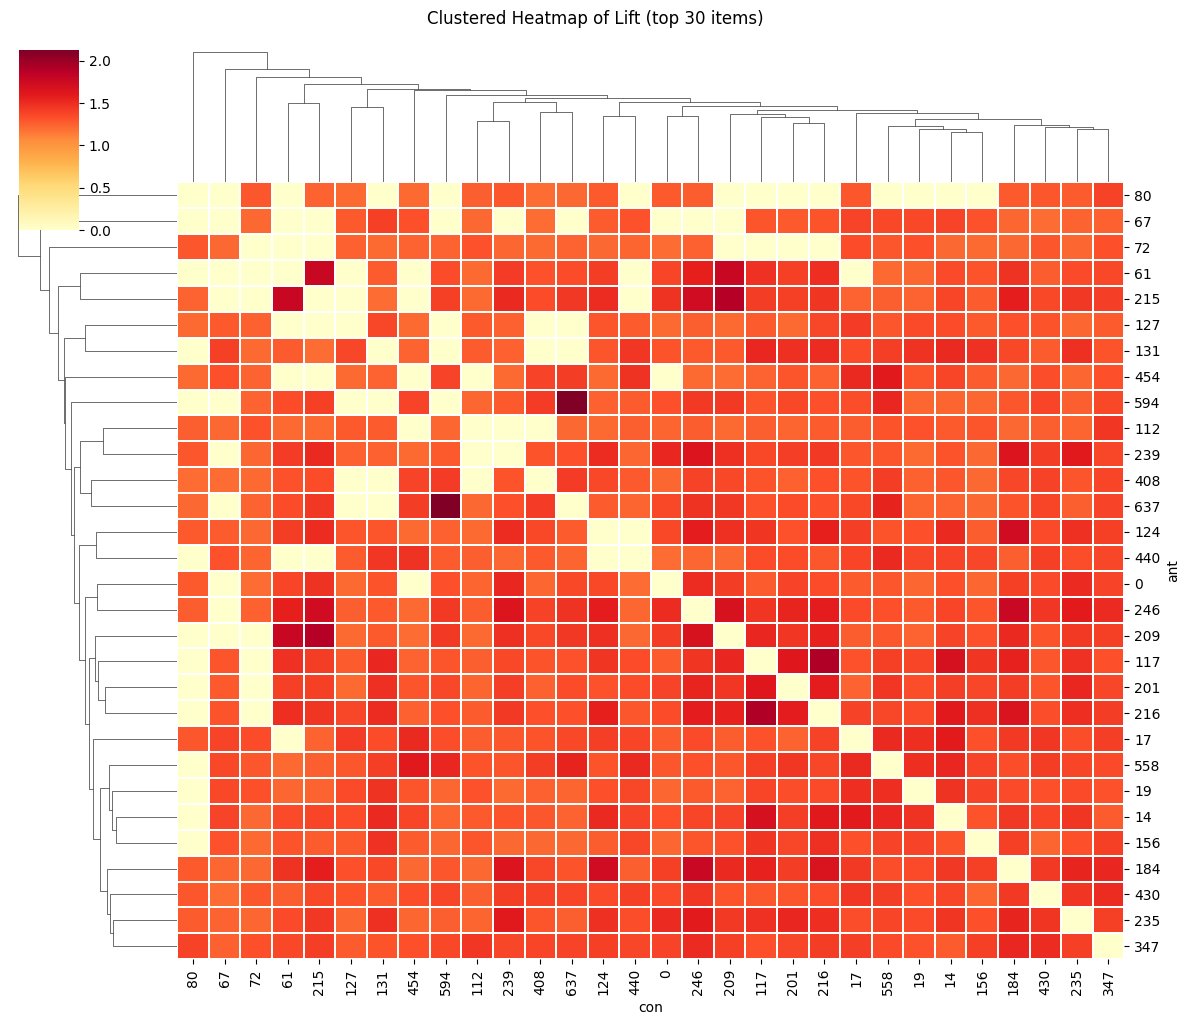

In [12]:
import seaborn as sns

# Build antecedent-consequent lift matrix (single-item rules only for clean heatmap)
single_rules = rules[
    (rules["antecedents"].apply(len) == 1) & (rules["consequents"].apply(len) == 1)
].copy()
single_rules["ant"] = single_rules["antecedents"].apply(lambda x: list(x)[0])
single_rules["con"] = single_rules["consequents"].apply(lambda x: list(x)[0])

# Pivot into matrix
lift_matrix = single_rules.pivot_table(index="ant", columns="con", values="lift", fill_value=0)

# Use top items by frequency to keep heatmap readable
top_n = 30
top_items = single_rules["ant"].value_counts().head(top_n).index.tolist()
lift_sub = lift_matrix.loc[
    lift_matrix.index.isin(top_items),
    lift_matrix.columns.isin(top_items)
]

if lift_sub.shape[0] > 1 and lift_sub.shape[1] > 1:
    g = sns.clustermap(lift_sub, cmap="YlOrRd", figsize=(12, 10),
                       linewidths=0.3, annot=False, dendrogram_ratio=0.15)
    g.fig.suptitle(f"Clustered Heatmap of Lift (top {top_n} items)", y=1.02)
    plt.show()
else:
    print("Not enough single-item rules to build a meaningful heatmap.")

## Parallel Coordinates Plot

Each line = one rule flowing from antecedent(s) to consequent(s).  
Useful for multi-item rules (e.g. {A, B} → {C}).

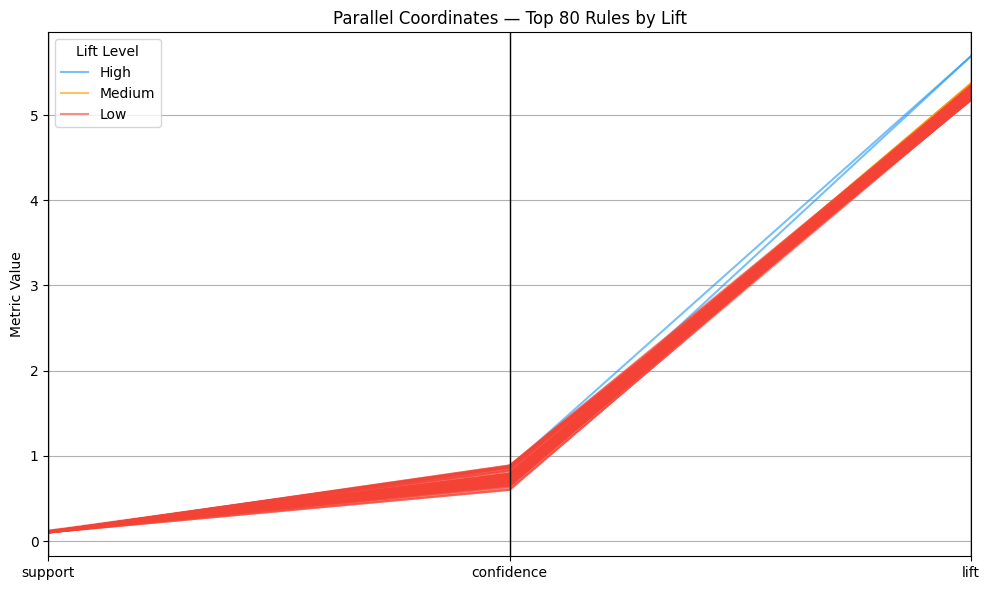

In [13]:
# Parallel coordinates: each rule shown as support / confidence / lift profile
from pandas.plotting import parallel_coordinates

top_pc = rules.nlargest(80, "lift")[["support", "confidence", "lift"]].copy()
# Bin lift into categories for coloring
top_pc["lift_bin"] = pd.cut(top_pc["lift"], bins=3, labels=["Low", "Medium", "High"])

fig, ax = plt.subplots(figsize=(10, 6))
parallel_coordinates(top_pc, class_column="lift_bin", ax=ax,
                     color=["#2196F3", "#FF9800", "#F44336"], alpha=0.6)
ax.set_title("Parallel Coordinates — Top 80 Rules by Lift")
ax.set_ylabel("Metric Value")
ax.legend(title="Lift Level", loc="upper left")
plt.tight_layout()
plt.show()

## Rating Distribution Validation

For the strongest rules, compare the rating of the consequent item when the antecedent is rated high (≥4) vs low (<2). Validates that the discovered groupings correspond to real shifts in user behavior.

C:\Users\ChunChunMaru\AppData\Local\Temp\ipykernel_32672\1916844588.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_to_plot, labels=labels)
C:\Users\ChunChunMaru\AppData\Local\Temp\ipykernel_32672\1916844588.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_to_plot, labels=labels)
C:\Users\ChunChunMaru\AppData\Local\Temp\ipykernel_32672\1916844588.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_to_plot, labels=labels)
C:\Users\ChunChunMaru\AppData\Local\Temp\ipykernel_32672\1916844588.py:28: MatplotlibDeprecationWarning: The 'labels' par

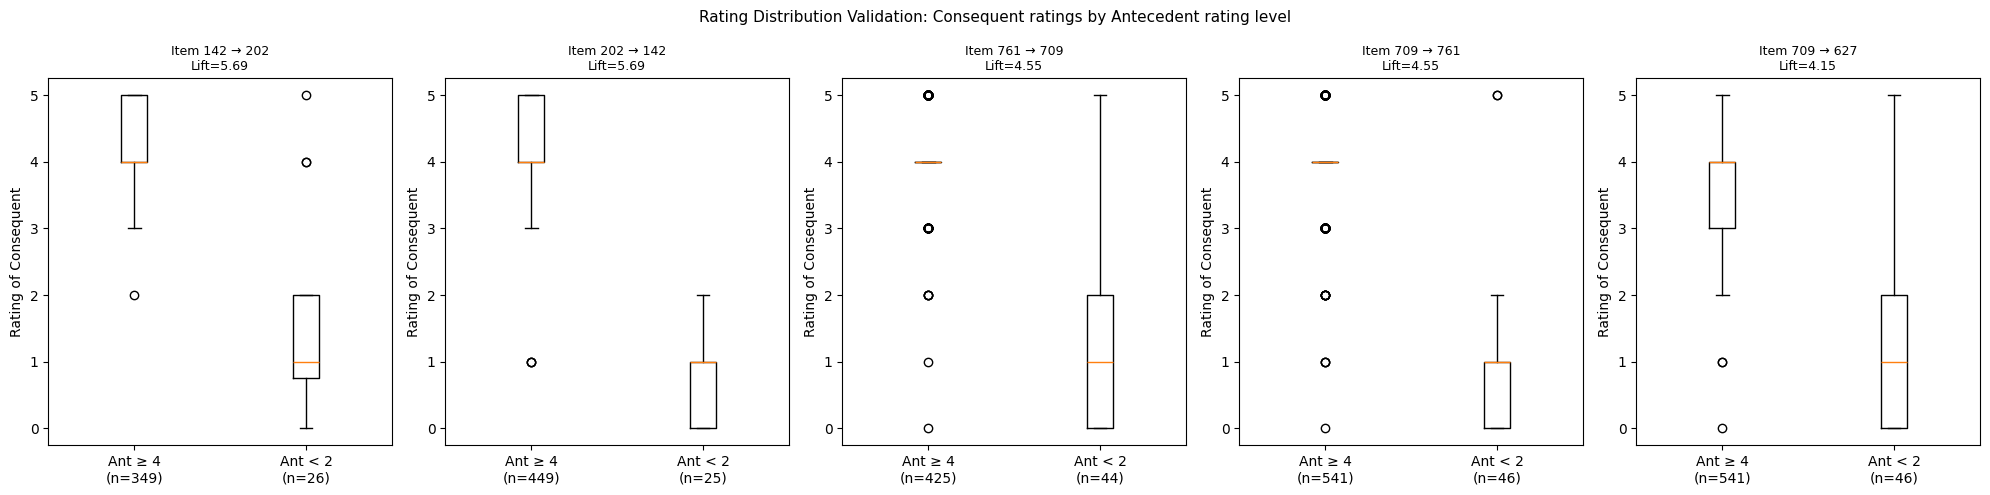

In [14]:
# Pick top 5 single-item rules by lift for validation boxplots
top_validation = single_rules.nlargest(5, "lift")

fig, axes = plt.subplots(1, len(top_validation), figsize=(4 * len(top_validation), 5), squeeze=False)
axes = axes.flatten()

for idx, (_, rule_row) in enumerate(top_validation.iterrows()):
    ant_item = rule_row["ant"]
    con_item = rule_row["con"]

    # Users who rated the antecedent item
    user_ratings = XX.pivot_table(index="user", columns="item", values="rating")

    if ant_item in user_ratings.columns and con_item in user_ratings.columns:
        high_mask = user_ratings[ant_item] >= 4
        low_mask = user_ratings[ant_item] < 2

        data_to_plot = []
        labels = []
        if high_mask.any():
            data_to_plot.append(user_ratings.loc[high_mask, con_item].dropna())
            labels.append(f"Ant ≥ 4\n(n={high_mask.sum()})")
        if low_mask.any():
            data_to_plot.append(user_ratings.loc[low_mask, con_item].dropna())
            labels.append(f"Ant < 2\n(n={low_mask.sum()})")

        if data_to_plot:
            axes[idx].boxplot(data_to_plot, labels=labels)
            axes[idx].set_title(f"Item {int(ant_item)} → {int(con_item)}\nLift={rule_row['lift']:.2f}", fontsize=9)
            axes[idx].set_ylabel("Rating of Consequent")

plt.suptitle("Rating Distribution Validation: Consequent ratings by Antecedent rating level", fontsize=11)
plt.tight_layout()
plt.show()